# 1. 환경 준비

In [2]:
#다음 라이브러리를 설치해주세요
!pip install sentencepiece
!pip install tqdm
!conda install -y -c conda-forge ipywidgets
!jupyter nbextension enable --py widgetsnbextension
!pip install torchinfo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 29.4 MB/s eta 0:00:00
Channels:
 - conda-forge
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.5.1
    latest version: 26.1.1

Please update conda by running

    $ conda update -n base -c conda-forge conda



## Package Plan ##

  environment location: /opt/conda

  added / updated specs:
    - ipywidgets


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2026.2.25  |       hbd8a1cb_0         144 KB  conda-forge
    certifi-2026.2.25          |     pyhd8ed1ab_0         148 KB  conda-forge
    ipywidgets-8.1.8           |     pyhd8ed1ab_0         112 KB  conda-forge
    openssl-3.6.1              |       h35e630c_1         3.0 MB  conda-forge
    ------------------------------------------------------------
                                         

In [3]:
DIR_DATA = "/home/jovyan/work/project/bert_pretrain/data"
DIR_MODEL = "/home/jovyan/work/project/bert_pretrain/models"

In [ ]:
# # 폴더 만들기
# !mkdir -p {DIR_DATA}
# !mkdir -p {DIR_MODEL}

In [ ]:
# # 한글 나무위키 코퍼스 다운로드
# !wget https://d3s0tskafalll9.cloudfront.net/media/documents/kowiki.txt.zip
# !mv kowiki.txt.zip ~/work/project/bert_pretrain/data
# !cd ~/work/project/bert_pretrain/data && unzip kowiki.txt.zip

# 2. Tokenizer 준비

1. SentencePiece 기반의 토크나이저를 준비

In [4]:
# imports
from __future__ import absolute_import, division, print_function, unicode_literals

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

from torchinfo import summary

from IPython.display import clear_output, display, update_display
from tqdm.notebook import tqdm 

import os
import re
import math
import numpy as np
import pandas as pd
import random
import collections
import json
import shutil
import zipfile
import copy
from datetime import datetime

import matplotlib.pyplot as plt
import sentencepiece as spm

random_seed = 1234
random.seed(random_seed)
np.random.seed(random_seed)

# torch version
print(torch.__version__)

2.7.1+cu118


## 모델과 vocab 만들기

- 8000의 vocab_size를 갖는 sentencepiece 모델을 생성
- BERT에 사용되는 [MASK], [SEP], [CLS] 등의 주요 특수문자가 vocab에 포함되어야 함

#### 직접 만들기
아래 작업은 약 n * 10분 소요됨 -> 미리 만들어놓은 파일 사용하기  

In [ ]:
# import sentencepiece as spm
# import os
# corpus_file = os.path.join(DIR_DATA, 'kowiki.txt')

# vocab_size = 8000 - 7

# spm.SentencePieceTrainer.train(\
#     f"--input={corpus_file} --model_prefix={prefix} --vocab_size={vocab_size + 7} --model_type=bpe --max_sentence_length=999999 --pad_id=0 --pad_piece=[PAD] --unk_id=1 --unk_piece=[UNK] --bos_id=2 --bos_piece=[BOS] --eos_id=3 --eos_piece=[EOS] --user_defined_symbols=[SEP],[CLS],[MASK]"
# )

# # ko_8000 파일은 /home/jovyan/work/project/bert_pretrain/models에 저장됨.

### 기존 단어장 파일 이용하기
이미 생성된 토크나이저 Loading해서 그 안에 담긴 단어장(vocab) 내용 확인하기

In [5]:
prefix = os.path.join(DIR_MODEL, 'ko_8000')

# 노드에서 제공한 단어장
# data_dir = '/home/jovyan/data'
# corpus_file = data_dir + '/kowiki.txt'
# prefix = data_dir + '/ko_8000'
# vocab_size = 8000

# 내가 생성한 단어장 vocab loading
vocab = spm.SentencePieceProcessor()
# vocab.load(f"{data_dir}/ko_8000.model")
vocab.load(f"{prefix}.model")
vocab_size = vocab.get_piece_size()
print(vocab_size)

8000


# 3. 데이터 전처리

### 3.1 MASK 생성

In [6]:
def create_pretrain_mask(tokens, mask_cnt, vocab_list):
    """
    마스크 생성
    :param tokens: tokens
    :param mask_cnt: mask 개수 (전체 tokens의 15%)
    :param vocab_list: vocab list (random token 용)
    :return tokens: mask된 tokens
    :return mask_idx: mask된 token의 index
    :return mask_label: mask된 token의 원래 값
    """
    # 단어 단위로 mask 하기 위해서 index 분할 (띄어쓰기)
    cand_idx = []
    for (i, token) in enumerate(tokens):
        if token == "[CLS]" or token == "[SEP]":
            continue
        if 0 < len(cand_idx) and not token.startswith(u"\u2581"):
            cand_idx[-1].append(i)
        else:
            cand_idx.append([i])

    # random mask를 위해서 순서를 섞음 (shuffle)
    random.shuffle(cand_idx)
    mask_lms = []
    for index_set in cand_idx:
        if len(mask_lms) >= mask_cnt:
            break
        if len(mask_lms) + len(index_set) > mask_cnt:
            continue
        dice = random.random()
        for index in index_set:
            masked_token = None
            if dice < 0.8:
                masked_token = "[MASK]"
            elif dice < 0.9:
                masked_token = tokens[index]
            else:
                masked_token = random.choice(vocab_list)
            mask_lms.append({"index": index, "label": tokens[index]})
            tokens[index] = masked_token

    # mask_lms 정렬 후 mask_idx, mask_label 추출 (sorted 사용)
    mask_lms = sorted(mask_lms, key=lambda x: x["index"])
    mask_idx = [p["index"] for p in mask_lms]
    mask_label = [p["label"] for p in mask_lms]

    return tokens, mask_idx, mask_label

### 3.2 NSP pair 생성

In [7]:
string = """추적추적 비가 내리는 날이었어
그날은 왠지 손님이 많아
첫 번에 삼십 전 둘째 번 오십 전
오랜만에 받아보는 십 전짜리 백통화 서푼에
손바닥 위엔 기쁨의 눈물이 흘러
컬컬한 목에 모주 한잔을 적셔
몇 달 포 전부터 콜록거리는 아내
생각에 그토록 먹고 싶다던
설렁탕 한 그릇을 이제는 살 수 있어
집으로 돌아가는 길 난 문득 떠올라
아내의 목소리가 거칠어만 가는 희박한 숨소리가
오늘은 왠지 나가지 말라던 내 옆에 있어 달라던
그리도 나가고 싶으면 일찍이라도 들어와 달라던
아내의 간절한 목소리가 들려와
나를 원망하듯 비는 점점 거세져
싸늘히 식어가는 아내가 떠올라 걱정은 더해져
난 몰라 오늘은 운수 좋은 날
난 맨날 이렇게 살 수 있으면 얼마나 좋을까"""

In [8]:
# NSP를 수행하기 위해 문장 단위로 쪼갠 후 서브워드 토크나이징
doc = [vocab.encode_as_pieces(line) for line in string.split("\n")]
doc[-1]

['▁난', '▁맨', '날', '▁이렇게', '▁살', '▁수', '▁있', '으면', '▁얼마', '나', '▁좋', '을', '까']

In [9]:
# 최대 길이
n_test_seq = 64
# 최소 길이
min_seq = 8
# [CLS], tokens_a, [SEB], tokens_b, [SEP]
max_seq = n_test_seq - 3

두 문장의 최대 길이를 유지하도록 trim을 적용한 후 50%의 확률로 true/false 케이스를 생성 (앞 뒤 문장 순서 바꿔서)

In [10]:
def trim_tokens(tokens_a, tokens_b, max_seq):
    """
    tokens_a, tokens_b의 길이를 줄임 최대 길이: max_seq
    :param tokens_a: tokens A
    :param tokens_b: tokens B
    :param max_seq: 두 tokens 길이의 최대 값
    """
    while True:
        total_length = len(tokens_a) + len(tokens_b)
        if total_length <= max_seq:
            break

        if len(tokens_a) > len(tokens_b):
            del tokens_a[0]
        else:
            tokens_b.pop()

#### NSP를 위한 코퍼스 생성 메서드

In [11]:
# [결과] Mask LM용 데이터셋과 NSP용 데이터셋이 결합된 하나의 데이터셋
def create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list):
    """
    doc별 pretrain 데이터 생성

    Args:
        vocab (Vocab): 토크나이저 vocab 객체 (단어-인덱스 매핑 정보 포함)
        doc (list of list of str): 문장 단위로 토크나이징된 문서
            예: [["안녕", "하세요"], ["반갑", "습니다"]]
        n_seq (int): 최대 시퀀스 길이 ([CLS], [SEP], [SEP] 3개 스페셜 토큰 포함)
        mask_prob (float): 전체 토큰 중 마스킹할 비율 (예: 0.15)
        vocab_list (list of str): 마스킹 시 랜덤 토큰 교체에 사용할 전체 vocab 토큰 리스트

    Returns:
        instances (list of dict): 생성된 pretrain 샘플 리스트. 각 dict는 아래 키를 포함:
            - tokens     (list of str) : 마스킹이 적용된 최종 토큰 시퀀스
                                         예: ["[CLS]", "안녕", "[MASK]", "[SEP]", "반갑", "[SEP]"]
            - segment    (list of int) : 각 토큰의 세그먼트 ID (문장 A=0, 문장 B=1)
                                         예: [0, 0, 0, 0, 1, 1]
            - is_next    (int)         : NSP 레이블 (1=실제 다음 문장, 0=랜덤 교체된 문장)
            - mask_idx   (list of int) : 마스킹된 토큰의 인덱스 리스트
                                         예: [2, 5]
            - mask_label (list of str) : 마스킹되기 전 원본 토큰 리스트 (정답 레이블)
                                         예: ["하세요", "습니다"]
    """
    max_seq = n_seq - 3

    instances = []
    current_chunk = []
    current_length = 0
    for i in range(len(doc)):

        current_chunk.append(doc[i])
        current_length += len(doc[i])
        if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):
            a_end = 1
            if 1 < len(current_chunk):
                a_end = random.randrange(1, len(current_chunk))
            tokens_a = []
            for j in range(a_end):
                tokens_a.extend(current_chunk[j])
            tokens_b = []
            for j in range(a_end, len(current_chunk)):
                tokens_b.extend(current_chunk[j])

            if random.random() < 0.5:
                is_next = 0
                tokens_t = tokens_a
                tokens_a = tokens_b
                tokens_b = tokens_t
            else:
                is_next = 1
            trim_tokens(tokens_a, tokens_b, max_seq)
            assert 0 < len(tokens_a)
            assert 0 < len(tokens_b)

            # 두 문장 사이에 segment 처리
            tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
            # 첫 번째 문장의 segment는 모두 0, 두 번째 문장은 1로 채움
            segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)
            tokens, mask_idx, mask_label = create_pretrain_mask(tokens, int((len(tokens) - 3) * mask_prob), vocab_list)

            instance = {
                "tokens": tokens,
                "segment": segment,
                "is_next": is_next,
                "mask_idx": mask_idx,
                "mask_label": mask_label
            }
            instances.append(instance)

            current_chunk = []
            current_length = 0
    return instances

### 3.3 데이터셋 완성

In [12]:
corpus_file = 'data/kowiki.txt'

# line count 확인
total = 0
with open(corpus_file, 'r') as in_f:
    for line in in_f:
        total += 1

total  # 3957761

3957761

In [13]:
def make_pretrain_data(vocab, in_file, out_file, n_seq, mask_prob=0.15):
    """
    입력 텍스트 파일을 읽어 BERT pretrain용 데이터를 생성하고 파일로 저장

    Args:
        vocab: SentencePiece vocab 객체 (토크나이징 및 id-token 변환에 사용)
        in_file (str): 입력 텍스트 파일 경로 (빈 줄로 단락 구분)
        out_file (str): pretrain 데이터를 저장할 출력 파일 경로 (JSONL 형식)
        n_seq (int): BERT 모델이 한 번에 받아들일 수 있는 최대 시퀀스 길이
        mask_prob (float): 마스킹 비율 (기본값: 0.15)

    Returns:
        None: 결과는 out_file에 한 줄씩 JSON으로 저장됨
            저장 형식 예시: {"tokens": [...], "segment": [...], "is_next": 1, "mask_idx": [...], "mask_label": [...]}

    Notes:
        - 입력 파일의 빈 줄을 단락 구분자로 사용하며, 단락 단위로 pretrain 인스턴스를 생성
        - vocab의 특수 토큰 7개(0~6번 id)는 마스킹 후보에서 제외
        - unknown 토큰도 마스킹 후보에서 제외
    """
    def save_pretrain_instances(out_f, doc):
        instances = create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list)
        for instance in instances:
            out_f.write(json.dumps(instance, ensure_ascii=False))
            out_f.write("\n")

    # 특수문자 7개 제외한 vocab_list 생성
    # 마스킹 시 랜덤 토큰으로 교체할 때 특수 토큰이 들어가지 않도록(학습에 영향)
    vocab_list = []
    for id in range(7, len(vocab)):
        if not vocab.is_unknown(id):        # 생성되는 단어 목록이 unknown인 경우는 제거합니다.
            vocab_list.append(vocab.id_to_piece(id))

    # line count 확인
    line_cnt = 0
    with open(in_file, "r") as in_f:
        for line in in_f:
            line_cnt += 1

    with open(in_file, "r") as in_f:
        with open(out_file, "w") as out_f:
            doc = []
            for line in tqdm(in_f, total=line_cnt):
                line = line.strip()
                if line == "":  # line이 빈줄 일 경우 (새로운 단락)
                    if 0 < len(doc):
                        save_pretrain_instances(out_f, doc)
                        doc = []
                else:  # line이 빈줄이 아닐 경우 tokenize 해서 doc에 저장
                    pieces = vocab.encode_as_pieces(line)
                    if 0 < len(pieces):
                        doc.append(pieces)
            if 0 < len(doc):  # 마지막에 처리되지 않은 doc가 있는 경우
                save_pretrain_instances(out_f, doc)
                doc = []

In [14]:
# 사전학습 데이터 파일
pretrain_json_path = 'data/mini_bert_pre_train_8000vocab.json'  

# 약 10분 소요 -> 파일 생성완료
# make_pretrain_data(vocab, corpus_file, pretrain_json_path, 128)  

In [15]:
# 총 라인수 파악
total = 0
with open(pretrain_json_path, "r") as f:
    print(next(f))
    for line in f:
        total += 1

total  # 918189

{"tokens": ["[CLS]", "▁지", "미", "[MASK]", "[MASK]", "▁제임스", "▁얼", "▁\"", "지", "미", "\"", "▁카", "터", "[MASK]", "[MASK]", "[MASK]", "▁192", "4", "년", "▁10", "월", "[MASK]", "[MASK]", "▁~", "▁)", "는", "[MASK]", "[MASK]", "[MASK]", "▁미국", "▁3", "9", "번째", "▁대통령", "▁(19", "7", "7", "년", "▁~", "▁1981", "년", ")", "이다", ".", "[SEP]", "▁지", "미", "▁카", "터", "는", "▁조지", "아", "주", "▁섬", "터", "▁카운", "티", "▁플", "레", "인", "스", "▁마을", "에서", "▁태어났다", ".", "▁조지", "아", "[MASK]", "[MASK]", "[MASK]", "[MASK]", "▁졸업", "하였다", ".", "▁그", "▁후", "▁해", "군에", "▁들어가", "▁전", "함", "·", "원", "자", "력", "·", "잠", "수", "함", "의", "▁승", "무", "원으로", "▁일", "하였다", ".", "▁195", "3", "년", "▁미국", "▁해군", "▁대", "위로", "▁예", "편", "하였고", "▁이후", "▁땅", "콩", "·", "면", "화", "▁등을", "[MASK]", "[MASK]", "▁많은", "[MASK]", "[MASK]", "▁벌", "었다", ".", "▁그의", "▁별", "명이", "▁\"", "땅", "콩", "[SEP]"], "segment": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1

918197

In [16]:
class Config:
    def __init__(self, config_dict):
        for key, value in config_dict.items():
            setattr(self, key, value)

# 초기 설정
"""
d_model (128): 각 토큰을 표현하는 벡터의 차원 수
n_seq (256): 모델이 한 번에 처리할 수 있는 최대 토큰 수
"""
config = Config({
    "d_model": 128,
    "n_head": 4,
    "d_head": 64,
    "dropout": 0.1,
    "d_ff": 1024,
    "layernorm_epsilon": 0.001,
    "n_layer": 3,
    "n_seq": 256,
    "n_vocab": vocab_size,
    "i_pad": 0
})
batch_size = 64

In [17]:
# 실제 생성된 vocab의 정보로 config값을 최신화한다.
config.n_vocab = vocab.get_piece_size() # SentencePiece 모델의 실제 단어 수
config.i_pad = vocab.pad_id()           # SentencePiece 모델의 패딩 ID 번호

print(f"단어장 크기: {config.n_vocab}, 패딩 ID: {config.i_pad}")

단어장 크기: 8000, 패딩 ID: 0


<위 코드 설명>  
Vocab 클래스 내부에서 [PAD], [CLS], [SEP], [MASK] 등 4개의 토큰을 자동으로 추가한다고 가정하면, 입력은 5000이었어도 실제 생성된 vocab_size는 5004가 될 수 있다.  
또한 실제 말뭉치(Corpus)의 단어 수가 적어 실제 단어장 크기가 4,982개가 될 수도 있다.  
이때 config.n_vocab = vocab.vocab_size를 해주지 않으면, 모델은 단어장이 5,000개인 줄 알고 멍청하게 빈 공간까지 계산하려고 하다가 에러가 나거나 성능이 떨어질 수 있다.

설계도(config)에서는 패딩을 0번으로 생각했지만, 실제 단어장을 만드는 과정에서 다른 번호(예: 1번)로 지정될 수 있기 때문에 이 값도 config에 다시 반영해준다.

### np.memmap을 사용해 데이터셋 로딩

만들어진 json 파일을 라인 단위로 읽어 들여 np.memmap에 로딩

In [18]:
def load_pre_train_data(vocab, filename, n_seq, count=None):
    """
    학습에 필요한 데이터를 로드
    :param vocab: vocab
    :param filename: 전처리된 json 파일
    :param n_seq: 시퀀스 길이 (number of sequence)
    :param count: 데이터 수 제한 (None이면 전체)
    :return enc_tokens: encoder inputs
    :return segments: segment inputs
    :return labels_nsp: nsp labels
    :return labels_mlm: mlm labels
    """
    total = 0
    with open(filename, "r") as f:
        for line in f:
            total += 1
            # 데이터 수 제한
            if count is not None and count <= total:
                break

    # np.memmap을 사용하면 메모리를 적은 메모리에서도 대용량 데이터 처리가 가능 함
    enc_tokens = np.memmap(filename='enc_tokens.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
    segments = np.memmap(filename='segments.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
    labels_nsp = np.memmap(filename='labels_nsp.memmap', mode='w+', dtype=np.int32, shape=(total,))
    labels_mlm = np.memmap(filename='labels_mlm.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
    
    with open(filename, "r") as f:
        for i, line in enumerate(tqdm(f, total=total)):
            if total <= i:
                print("data load early stop", total, i)
                break
            data = json.loads(line)
            # encoder token
            enc_token = [vocab.piece_to_id(p) for p in data["tokens"]]
            enc_token += [0] * (n_seq - len(enc_token))  # 문장이 n_seq보다 짧으면 뒤를 모두 0으로 패딩
            # segment
            segment = data["segment"]
            segment += [0] * (n_seq - len(segment))
            # nsp label
            label_nsp = data["is_next"]
            # mlm label
            # 전체 128칸 중 마스킹된 위치(mask_idx)에만 정답 단어 ID를 적고, 나머지는 0으로 채움
            mask_idx = np.array(data["mask_idx"], dtype=np.int32)
            mask_label = np.array([vocab.piece_to_id(p) for p in data["mask_label"]], dtype=np.int32)
            # label_mlm = np.full(n_seq, dtype=np.int32, fill_value=0)
            label_mlm = np.full(n_seq, dtype=np.int32, fill_value=-100)
            label_mlm[mask_idx] = mask_label

            assert len(enc_token) == len(segment) == len(label_mlm) == n_seq

            enc_tokens[i] = enc_token
            segments[i] = segment
            labels_nsp[i] = label_nsp
            labels_mlm[i] = label_mlm

    return (enc_tokens, segments), (labels_nsp, labels_mlm)

<위 코드 설명>  
- enc_tokens: 단어 번호(id)
- segments: 문장 구역(0, 1)
- labels_nsp: 다음 문장이 맞는지 (0, 1)
- labels_mlm: 빈칸(MASK)에 들어갈 원래 단어 번호

In [19]:
# 학습 데이터 로드

# 전체 학습 데이터 중 918,188건 메모리에 로딩
# pre_train_inputs: 리스트 or ndarray
# 92만 건이 CPU RAM에, 배치는 GPU에 → 메모리 이중 사용되므로 위험
pre_train_inputs, pre_train_labels = load_pre_train_data(
    vocab, pretrain_json_path, config.n_seq, count=total)

print(type(pre_train_inputs))
print(type(pre_train_inputs[0]))

  0%|          | 0/918197 [00:00<?, ?it/s]

data load early stop 918197 918197
<class 'tuple'>
<class 'numpy.memmap'>


In [20]:
# 데이터 확인
# (enc_tokens, segments), (labels_nsp, labels_mlm)
print(pre_train_inputs[0][0])  # enc_tokens: 단어 번호(id)
print(pre_train_labels[1][0])  # labels_mlm: 빈칸(MASK)에 들어갈 원래 단어 번호
print(pre_train_inputs[1][0])  # segments: 문장 구역(0, 1)
print(pre_train_labels[0][0])  # labels_nsp: 다음 문장이 맞는지 (0, 1)
print("--- 복원한 입력 문장 ---")
print(vocab.decode_ids(pre_train_inputs[0][0].tolist()))
print("--- 마스크 정답 토큰들 ---")
# 정답 토큰들 보기
print([vocab.id_to_piece(i) for x, i in zip(pre_train_inputs[0][0].tolist(), pre_train_labels[1][0].tolist()) if x == 6])

[   5   18 3679    6    6 3324 1042  104 3603 3679 3711  207 3707    6
    6    6  810 3659 3618  160 3655    6    6  203  241 3595    6    6
    6  243   49 3625  796  663 1648 3675 3675 3618  203 3009 3618 3609
   16 3592    4   18 3679  207 3707 3595 1756 3623 3639  630 3707 3568
 3828  429 3733 3621 3619 1370   10 1607 3592 1756 3623    6    6    6
    6 1135   52 3592   13   81   87 1502 2247   25 3772 3866 3660 3624
 3806 3866 4189 3629 3772 3594  249 3718 1233   33   52 3592  479 3645
 3618  243 2780   14 1510  168 3870  414  166 1697 4283 3866 3696 3676
  593    6    6  399    6    6  813   17 3592  307  587  930  104 4306
 4283    4    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0 

# 4. BERT 모델 구현

### 유틸리티 함수 정의

In [21]:
# 패딩 마스크와 앞부분 마스크 더해주는 함수 정의
def get_pad_mask(tokens, i_pad=0):
    """
    pad mask 계산하는 함수
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: pad mask (pad: 1, other: 0)
    """
    mask = (tokens == i_pad).float()
    mask = mask.unsqueeze(1)
    return mask

def get_ahead_mask(tokens, i_pad=0):
    """
    ahead mask 계산하는 함수
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: ahead and pad mask (ahead or pad: 1, other: 0)
    """
    n_seq = tokens.size(1)
    ahead_mask = 1 - torch.tril(torch.ones((n_seq, n_seq)))
    ahead_mask = ahead_mask.unsqueeze(0)
    pad_mask = get_pad_mask(tokens, i_pad)
    mask = torch.maximum(ahead_mask, pad_mask)
    return mask

def gelu(x):
    """
    gelu activation 함수
    :param x: 입력 값
    :return: gelu activation result
    """
    return 0.5 * x * (1 + torch.tanh(math.sqrt(2 / math.pi) * (x + 0.044715 * torch.pow(x, 3))))

# 가중치(Kernel/Weight)을 초기화
def kernel_initializer(stddev=0.02):
    """
    parameter initializer 생성
    :param stddev: 생성할 랜덤 변수의 표준편차
    """
    # 평균이 0, 표준편차가 stddev인 정규 분포에서 값을 뽑되, 표준편차의 2배를 벗어나는 값은 버리고 다시 뽑음
    # stddev=0.02: BERT 논문에서 제안된 값
    return torch.nn.init.trunc_normal_  

# 편향(Bias)을 초기화
def bias_initializer():
    """
    bias initializer 생성
    """
    return torch.zeros_  # 모든 편향 값을 0으로 초기화

### embedding 레이어 쌓기!

#### Token Embedding

In [22]:
class SharedEmbedding(nn.Module):
    """
    Weighed Shared Embedding Class
    """
    def __init__(self, config, name="weight_shared_embedding"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.n_vocab = config.n_vocab
        self.d_model = config.d_model
        self.shared_weights = nn.Parameter(torch.empty(self.n_vocab, self.d_model))
        nn.init.trunc_normal_(self.shared_weights, std=0.02)  # TensorFlow와 동일한 초기화 적용

    def forward(self, inputs, mode="embedding"):
        """
        layer 실행
        :param inputs: 입력
        :param mode: 실행 모드
        :return: embedding or linear 실행 결과
        """
        # mode가 embedding일 경우 embedding lookup 실행
        if mode == "embedding":
            return self._embedding(inputs)
        # mode가 linear일 경우 linear 실행
        elif mode == "linear":
            return self._linear(inputs)
        # mode가 기타일 경우 오류 발생
        else:
            raise ValueError(f"mode {mode} is not valid.")

    def _embedding(self, inputs):
        """
        embedding lookup
        :param inputs: 입력
        """
        inputs = torch.clamp(inputs, max=self.shared_weights.size(0) - 1)

        return self.shared_weights[inputs.long()]

    def _linear(self, inputs):  # (bs, n_seq, d_model)
        """
        linear 실행
        :param inputs: 입력
        """
        n_batch, n_seq, _ = inputs.shape
        inputs = inputs.view(-1, self.d_model)  # (bs * n_seq, d_model)
        outputs = torch.matmul(inputs, self.shared_weights.T)
        outputs = outputs.view(n_batch, n_seq, self.n_vocab)  # (bs, n_seq, n_vocab)
        return outputs

### Position Embedding

- 트랜스포머: 사인 코사인 함수를 이용해 Positional Encoding을 통해 토큰의 위치를 학습
- BERT: Positon Embedding 사용. (위치 정보가 담긴 임베딩 레이어를 하나 더 사용)

In [23]:
# 1. 위치 정보가 담긴 임베딩 레이어를 하나 더 사용해 Position Embedding 벡터 학습
# 2. 1의 결과물인 'Position Embedding'을 BERT의 입력에 더해줌.
class PositionEmbedding(nn.Module):
    """
    Position Embedding Class
    """
    def __init__(self, config, name="position_embedding"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.embedding = nn.Embedding(config.n_seq, config.d_model)
        nn.init.trunc_normal_(self.embedding.weight, std=0.02)

    def forward(self, inputs):
        """
        layer 실행
        :param inputs: 입력
        :return embed: position embedding lookup 결과
        """
        position = torch.cumsum(torch.ones_like(inputs), dim=1) - 1
        position = position.long()
        embed = self.embedding(position)
        return embed

### Segment Embedding

상대적으로 간단하므로 별도 레이어 구현하지 않고 BERT 클래스에 포함시키겠음.

In [24]:
# Transformer의 ScaleDotProductAttention
class ScaleDotProductAttention(nn.Module):
    """
    Scale Dot Product Attention Class
    """
    def __init__(self, name="scale_dot_product_attention"):
        """
        생성자
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

    def forward(self, Q, K, V, attn_mask):
        """
        layer 실행
        :param Q: Q value
        :param K: K value
        :param V: V value
        :param attn_mask: 실행 모드
        :return attn_out: attention 실행 결과
        """
        attn_score = torch.matmul(Q, K.transpose(-2, -1))
        scale = torch.sqrt(torch.tensor(K.shape[-1], dtype=torch.float32))
        attn_scale = attn_score / scale
        attn_scale = attn_scale - (attn_mask * 1e9)
        attn_prob = F.softmax(attn_scale, dim=-1)
        attn_out = torch.matmul(attn_prob, V)
        return attn_out

In [25]:
# Transformer의 ScaleDotProductAttention을 활용한 MultiHeadAttention
class MultiHeadAttention(nn.Module):
    """
    Multi Head Attention Class
    """
    def __init__(self, config, name="multi_head_attention"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.d_model = config.d_model
        self.n_head = config.n_head
        self.d_head = config.d_head

        # Q, K, V input dense layer
        self.W_Q = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_K = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_V = nn.Linear(config.d_model, config.n_head * config.d_head)
        # Scale Dot Product Attention class
        self.attention = ScaleDotProductAttention()
        # output dense layer
        self.W_O = nn.Linear(config.n_head * config.d_head, config.d_model)

    def forward(self, Q, K, V, attn_mask):
        """
        layer 실행
        :param Q: Q value
        :param K: K value
        :param V: V value
        :param attn_mask: 실행 모드
        :return attn_out: attention 실행 결과
        """
        batch_size = Q.shape[0]

        # reshape Q, K, V, attn_mask
        Q_m = self.W_Q(Q).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        K_m = self.W_K(K).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        V_m = self.W_V(V).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        attn_mask_m = attn_mask.unsqueeze(1)

        # Scale Dot Product Attention 실행
        attn_out = self.attention(Q_m, K_m, V_m, attn_mask_m)
        # (batch_size, n_seq, n_head, d_head)로 변환 후, (batch_size, n_seq, d_model)로 reshape
        attn_out_m = attn_out.transpose(1, 2).contiguous()  # (batch_size, n_seq, n_head, d_head)
        attn_out = attn_out_m.view(batch_size, -1, self.n_head * self.d_head)  # (batch_size, n_seq, d_model)
        attn_out = self.W_O(attn_out)  # (batch_size, n_seq, d_model)

        return attn_out

위 두 클래스를 바탕으로 트랜스포머 Encoder 레이어 구성

In [26]:
# 각 토큰의 위치(position)마다 독립적으로(wise) 동일한 FFN 적용
class PositionWiseFeedForward(nn.Module):
    """
    Position Wise Feed Forward Class
    """
    def __init__(self, config, name="feed_forward"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.W_1 = nn.Linear(config.d_model, config.d_ff)
        self.W_2 = nn.Linear(config.d_ff, config.d_model)

        self.gelu = nn.GELU()

    def forward(self, inputs):
        """
        입력 (d_model) → Linear → GELU(활성화 함수) → Linear → 출력 (d_model)
        """
        ff_val = self.W_2(self.gelu(self.W_1(inputs)))
        return ff_val

In [27]:
# Encoder Layer: BERT 내부에서 문장을 이해하기 위해 Attention 연산을 수행하는 층
class EncoderLayer(nn.Module):
    """
    Encoder Layer Class
    """
    def __init__(self, config, name="encoder_layer"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        # MultiHeadAttention
        self.self_attention = MultiHeadAttention(config)
        self.norm1 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.ffn = PositionWiseFeedForward(config)
        self.norm2 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_embed, self_mask):
        """
        layer 실행
        :param enc_embed: enc_embed 또는 이전 EncoderLayer의 출력
        :param self_mask: enc_tokens의 pad mask
        :return enc_out: EncoderLayer 실행 결과
        """
        self_attn_val = self.self_attention(enc_embed, enc_embed, enc_embed, self_mask)
        norm1_val = self.norm1(enc_embed + self.dropout(self_attn_val))

        ffn_val = self.ffn(norm1_val)
        enc_out = self.norm2(norm1_val + self.dropout(ffn_val))

        return enc_out

## 최종 구성

### BERT 레이어

In [28]:
class BERT(nn.Module):
    """
    BERT Class
    """
    def __init__(self, config):
        """
        생성자
        :param config: Config 객체
        """
        super(BERT, self).__init__()

        self.i_pad = config.i_pad
        self.embedding = SharedEmbedding(config)
        self.position = PositionEmbedding(config)
        
        # Segment embedding layer - 2개의 행을 가진 임베딩 테이블 생성 (0번을 위한 벡터 하나, 1번을 위한 벡터 하나)
        self.segment = nn.Embedding(2, config.d_model)  
        self.norm = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.encoder_layers = nn.ModuleList([EncoderLayer(config, name=f"encoder_layer_{i}") for i in range(config.n_layer)])

        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_tokens, segments):
        """
        layer 실행
        :param enc_tokens: 입력 token들
        :param segments: 입력 segment들
        :return logits_cls: CLS 토큰에 대한 예측
        :return logits_lm: Masked Language Modeling 예측
        """
        enc_self_mask = get_pad_mask(enc_tokens, self.i_pad)

        enc_embed = self.get_embedding(enc_tokens, segments)

        enc_out = self.dropout(enc_embed)

        for encoder_layer in self.encoder_layers:
            enc_out = encoder_layer(enc_out, enc_self_mask)

        logits_cls = enc_out[:, 0]
        logits_lm = self.embedding(enc_out, mode="linear")
        return logits_cls, logits_lm

    def get_embedding(self, tokens, segments):
        """
        token embedding, position embedding lookup
        :param tokens: 입력 tokens
        :param segments: 입력 segments
        :return embed: embedding 결과
        """
        # 세가지 임베딩을 더함
        # self.segment(segments): segments(예. [[0, 0, 0, 1, 1], [1, 1, 0, 0, 0]])의 각 값(0 또는 1)을 인덱스로 사용해서 해당 행의 벡터를 가져옴.
        embed = self.embedding(tokens) + self.position(tokens) + self.segment(segments)
        embed = self.norm(embed)
        return embed


### 위 BERT 레이어를 바탕으로 최종적으로 만들어질 pretrain용 BERT 모델 구성

BERT의 핵심 능력은 '문장의 맥락을 잘 파악하는 것'.  
맥락을 파악한 결과물 `enc_out`을 바탕으로 다음 문장이 이어지는지(NSP) 빈칸에 들어갈 단어는 무엇인지(MLM)같은 사전학습을 수행하게 하는 코드.

In [29]:
# BERT 모델 전체를 감싸는 사전 학습용 Wrapper(포장지) 정의
class PooledOutput(nn.Module):
    """
    여러 데이터 중 대표적인 값을 뽑아냄.
    BERT 모델이 내놓은 각 단어의 벡터 중 문장 전체의 의미를 대표하는 딱 하나의 벡터
    (보통 첫 번째인 [CLS] 토큰)를 골라내서 작업(분류, 판단 등)에 적합하게 한 번 더 가공
    """
    def __init__(self, config, n_output, name="pooled_output"):
        super(PooledOutput, self).__init__()

        self.dense1 = nn.Linear(config.d_model, config.d_model)
        self.dense2 = nn.Linear(config.d_model, n_output, bias=False)

    def forward(self, inputs):
        """
        forward pass
        :param inputs: 모델의 출력 (예: logits_cls)
        :return: softmax된 결과
        """
        # outputs = F.tanh(self.dense1(inputs))  # BERT 논문에서 tanh대신 GELU 사용(출력이 -1~1 사이로 포화될 시 기울기가 0에 가까워짐)
        outputs = F.gelu(self.dense1(inputs))  # GELU로 대체
        
        outputs = self.dense2(outputs)
        # outputs = F.softmax(outputs, dim=-1)  # <- 이 줄 삭제
        return outputs  # Raw Logits(점수)만 반환

class PreTrainModel(nn.Module):
    def __init__(self, config):
        super(PreTrainModel, self).__init__()
        self.bert = BERT(config)
        self.pooled_output = PooledOutput(config, 2)

    def forward(self, enc_tokens, segments):
        enc_tokens = enc_tokens.long()
        segments = segments.long()

        logits_cls, logits_lm = self.bert(enc_tokens, segments)

        outputs_nsp = self.pooled_output(logits_cls)  # Logits
        outputs_mlm = logits_lm  
        
        """
        아래 두 코드 제거
        outputs_nsp = F.softmax(logits_cls, dim=-1)  # 소프트맥스를 또?
        outputs_mlm = F.softmax(logits_lm, dim=-1)  # 소프트맥스를 또?
        """
        return outputs_nsp, outputs_mlm

def build_model_pre_train(config):
    return PreTrainModel(config)

# 5. pretrain 모델 구성

### loss와 accuracy
- 학습 데이터의 label이 정수로 변환되었으므로 loss 함수는 `SparseCategoricalCrossentropy`와 동일한 역할을 수행하는 `F.cross_entropy` 사용
- MLM task에 대해 더 잘 학습하도록 loss를 20배 증가시켜 줌.

In [30]:
def lm_loss(y_true, y_pred):
    """
    loss 계산 함수
    :param y_true: 정답 (bs, n_seq)
    :param y_pred: 예측 값 (bs, n_seq, n_vocab)
    """
    # F.cross_entropy = SparseCategoricalCrossentropy
    loss = F.cross_entropy(y_pred.view(-1, y_pred.size(-1)), y_true.view(-1), reduction='none')
    # pad(0) 인 부분 mask
    mask = (y_true != 0).float()
    loss = loss * mask
    return loss.mean() * 20   # mlm을 더 잘 학습하도록 20배 증가 시킴

In [31]:
def lm_acc(y_true, y_pred):
    """
    acc 계산 함수
    :param y_true: 정답 (bs, n_seq)
    :param y_pred: 예측 값 (bs, n_seq, n_vocab)
    """
    # 정답 여부 확인
    y_pred_class = torch.argmax(y_pred, dim=-1).float()
    matches = (y_true == y_pred_class).float()
    # pad(0) 인 부분 mask
    mask = (y_true != 0).float()
    matches *= mask
    # 정확도 계산
    accuracy = matches.sum() / mask.sum().clamp(min=1)
    return accuracy

### Learning Rate 스케줄링 구현
WarmUp 이후 consine 형태로 감소하는 스케줄 적용  
-> 최근에는 Learning Rate를 단순히 감소시키기 보다는 진동하면서 최적점을 찾아가는 방식을 많이 사용한다.
(여기서 다양한 방법 찾아서 적용시켜 보는 것도 성능 up에 도움됨)

In [32]:
# 학습률 고정 문제로 수정한 코드
class CosineSchedule:
    """
    CosineSchedule Class for learning rate scheduling
    """
    def __init__(self, optimizer=None, train_steps=4000, warmup_steps=500, max_lr=2.5e-4):
        """
        생성자
        :param optimizer: Optimizer (PyTorch optimizer)
        :param train_steps: 총 학습 step 수
        :param warmup_steps: warmup steps
        :param max_lr: 최대 learning rate
        """
        self.optimizer = optimizer
        self.train_steps = train_steps
        self.warmup_steps = warmup_steps
        self.max_lr = max_lr
        self.step_num = 0

    def get_lr(self):
        """
        learning rate 계산
        :return: 계산된 learning rate
        """
        if self.step_num <= self.warmup_steps:
            lr = (self.step_num / self.warmup_steps) * self.max_lr
        else:
            progress = (self.step_num - self.warmup_steps) / max(1, self.train_steps - self.warmup_steps)
            lr = 0.5 * self.max_lr * (1 + math.cos(math.pi * progress))
        return lr

    def step(self):
        """
        Step 함수: 매 학습 step마다 호출하여 learning rate를 업데이트
        """

        """ 
        문제점: self.optimizer를 생성자(__init__)에서 받아오긴 했지만, 
        step() 함수 안에서 그 옵티마이저의 실제 학습률을 업데이트하는 코드가 빠져 있었습니다.
        """        
        self.step_num += 1
        lr = self.get_lr()

        # 옵티마이저의 학습률을 실제로 업뎃시켜주는 코드
        if self.optimizer is not None:  # 추가
            for param_group in self.optimizer.param_groups:
                param_group['lr'] = lr
    
        return lr

### 데이터 노출 횟수 결정

train_steps는 모델이 가중치를 몇 번 업데이트할지를 결정

#### 학습률 스케줄 변화 그래프 보기
디버깅용. 맛보기.  
train_step: 4000, warmup_steps: 500   
모델이 언어의 복잡한 문맥을 다 배우기도 전에 학습이 끝나버릴 가능성 큼.

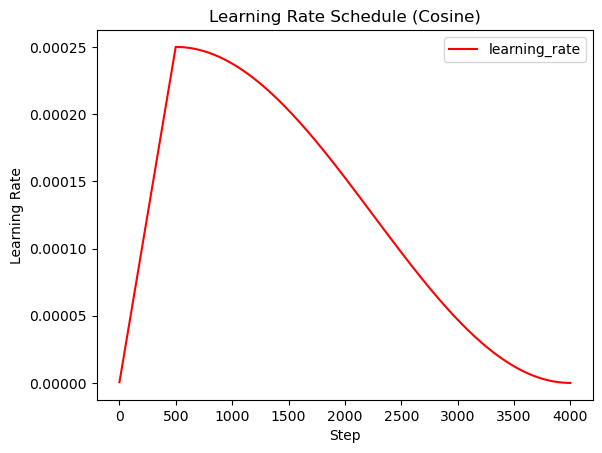

In [33]:
# 더비깅용, 맛보기
test_schedule = CosineSchedule(train_steps=4000, warmup_steps=500)
lrs = []
for step_num in range(4000):
    lrs.append(test_schedule.step())

# draw
plt.plot(lrs, 'r-', label='learning_rate')
plt.xlabel('Step')
plt.ylabel('Learning Rate')
plt.legend()
plt.title('Learning Rate Schedule (Cosine)')
plt.show()

### 모델 빌드하기

In [34]:
# 모델 생성
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

pre_train_model = build_model_pre_train(config)
pre_train_model.to(device)

PreTrainModel(
  (bert): BERT(
    (embedding): SharedEmbedding()
    (position): PositionEmbedding(
      (embedding): Embedding(256, 128)
    )
    (segment): Embedding(2, 128)
    (norm): LayerNorm((128,), eps=0.001, elementwise_affine=True)
    (encoder_layers): ModuleList(
      (0-2): 3 x EncoderLayer(
        (self_attention): MultiHeadAttention(
          (W_Q): Linear(in_features=128, out_features=256, bias=True)
          (W_K): Linear(in_features=128, out_features=256, bias=True)
          (W_V): Linear(in_features=128, out_features=256, bias=True)
          (attention): ScaleDotProductAttention()
          (W_O): Linear(in_features=256, out_features=128, bias=True)
        )
        (norm1): LayerNorm((128,), eps=0.001, elementwise_affine=True)
        (ffn): PositionWiseFeedForward(
          (W_1): Linear(in_features=128, out_features=1024, bias=True)
          (W_2): Linear(in_features=1024, out_features=128, bias=True)
          (gelu): GELU(approximate='none')
        

In [35]:
from torchinfo import summary
# 모델 구조 확인 -> summary
# 더미 데이터를 이용해 모델의 파라미터 수, 레이어 구성을 확인
enc_tokens_example = torch.randint(0, config.n_vocab, (10, config.n_seq), dtype=torch.long).to(device)
segments_example = torch.randint(0, 2, (10, config.n_seq), dtype=torch.long).to(device)
summary(pre_train_model, [(10, config.n_seq), (10, config.n_seq)])

Layer (type:depth-idx)                                       Output Shape              Param #
PreTrainModel                                                [10, 2]                   --
├─BERT: 1-1                                                  [10, 128]                 --
│    └─SharedEmbedding: 2-1                                  [10, 256, 128]            1,024,000
│    └─PositionEmbedding: 2-2                                [10, 256, 128]            --
│    │    └─Embedding: 3-1                                   [10, 256, 128]            32,768
│    └─Embedding: 2-3                                        [10, 256, 128]            256
│    └─LayerNorm: 2-4                                        [10, 256, 128]            256
│    └─Dropout: 2-5                                          [10, 256, 128]            --
│    └─ModuleList: 2-6                                       --                        --
│    │    └─EncoderLayer: 3-2                                [10, 256, 128]       

### 목표: 전체 파라미터 사이즈가 1M 정도 되는 Mini 모델

#### 파라미터 개수 합산
- 임베딩 층에서 약 78만개
    - $n\_vocab(8000) \times d\_model(96) \approx 768,000$
- 인코더 레이어에서 약 15만개
    - $n\_layer(2) \times [Self\text{-}Attention(4 \times 96^2) + FFN(2 \times 96 \times 128)] \approx 147,456$
- NSP와 MLM 예측을 위한 출력층(Head) 파라미터들이 약 1만개
  
총합 약 0.95M(95만개)

### 데이터셋 준비

In [36]:
# 데이터셋 준비 및 모니터링 세팅
class PreTrainDataset(Dataset):
    def __init__(self, inputs, labels):
        (self.enc_tokens, self.segments) = inputs
        (self.labels_nsp, self.labels_mlm) = labels
    
    def __len__(self):
        return len(self.enc_tokens)
    
    def __getitem__(self, idx):
        # memmap에서 배치 단위로 그때그때 읽음
        return (
            torch.tensor(self.enc_tokens[idx], dtype=torch.long),
            torch.tensor(self.segments[idx], dtype=torch.long),
            torch.tensor(self.labels_nsp[idx], dtype=torch.long),
            torch.tensor(self.labels_mlm[idx], dtype=torch.long),
        )

# pre_train_inputs: (리스트/넘파이 형태)

"""
전체 데이터를 한꺼번에 GPU로 보냄. 
리스트 전체가 GPU 메모리에 올라간 상태로 저장됨
데이터가 크면 GPU 메모리를 처음부터 전부 차지
"""
# pre_train_inputs_tensors = [torch.tensor(np.array(x)).to(device) for x in pre_train_inputs]
# pre_train_labels_tensors = [torch.tensor(np.array(x)).to(device) for x in pre_train_labels]


"""
텐서가 CPU에 머뭄.
나중에 학습 루프에서 배치 단위로 .to(device) 호출 시 그때그때 GPU로 이동.
배치 하나를 GPU로 보내고 → 학습하고 → 다음 배치로 교체되면 이전 배치는 GPU 메모리에서 사라짐.
CPU에 있는 원본 데이터는 그대로 유지되면서 배치 크기만큼만 GPU를 점유 -> 메모리 효율적
"""
# ❌ (전체를 tensor로 변환 - memmap 장점 사라짐)
# pre_train_inputs_tensors = [torch.tensor(np.array(x)) for x in pre_train_inputs]
# pre_train_labels_tensors = [torch.tensor(np.array(x)) for x in pre_train_labels]


# ✅ 수정 (memmap에서 배치 단위로 그때그때 읽음)
train_dataset = PreTrainDataset(pre_train_inputs, pre_train_labels)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

print(f"Total dataset size: {len(train_dataset)}")

Total dataset size: 918197


### 모델 학습 함수 정의

In [37]:
import ipywidgets as widgets

def train_bert_model(
    pre_train_model, 
    train_dataloader, 
    optimizer, 
    learning_rate_scheduler, 
    config, 
    loss_fn_nsp, 
    loss_fn_mlm, 
    history, 
    epochs, 
    start_epoch=0,
    DIR_MODEL=DIR_MODEL,
    file_name="mini_bert_pre_train_epoch"
):
    """
    BERT 사전 학습 루프를 수행하는 함수 (5행 2열 대시보드 버전)
    """
    total_training_steps = len(train_dataloader) * epochs
    step_lrs = []
    step_losses = []

    # ✅ 그래프 위젯 영역 고정
    graph_out = widgets.Output()
    display(graph_out)

    # ✅ 도화지 한 번만 생성
    fig, ax1 = plt.subplots(figsize=(12, 4))
    ax2_container = [ax1.twinx()]
    
    for epoch in range(start_epoch, start_epoch + epochs):
        pre_train_model.train()
        total_loss = 0
        total_nsp_loss = 0
        total_mlm_loss = 0
        total_nsp_acc = 0
        total_mlm_acc = 0
        total_mlm_ppl = 0

        # 진행상황 표시를 위해 tqdm으로 DataLoader 감싸주기
        progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{epochs}")

        # for batch in train_dataloader:
        for i, batch in enumerate(progress_bar):
            # 배치를 꺼낼 때마다 GPU장치로 옮겨주기
            enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = [x.to(device) for x in batch]
            
            optimizer.zero_grad()

            logits_nsp, logits_mlm = pre_train_model(enc_tokens_batch, segments_batch)

            labels_nsp_batch = labels_nsp_batch.long()
            labels_mlm_batch = labels_mlm_batch.long()

            loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_batch)
            loss_mlm = loss_fn_mlm(logits_mlm.view(-1, logits_mlm.shape[-1]), labels_mlm_batch.view(-1))

            # MLM Loss를 기반으로 PPL 계산 (배치 단위)
            ppl_batch = torch.exp(loss_mlm).item()
            total_mlm_ppl += ppl_batch # total_mlm_ppl 변수는 에포크 시작 부분에 0으로 초기화 필요

            total_loss_batch = loss_nsp + loss_mlm
            total_loss += total_loss_batch.item()
            total_nsp_loss += loss_nsp.item()
            total_mlm_loss += loss_mlm.item()

            total_loss_batch.backward()

            # --- 가중치 업데이트 후 스케줄러 스텝 진행 ---
            optimizer.step()
            learning_rate_scheduler.step() # <- LR이 실제로 변하는 부분

            nsp_acc = (logits_nsp.argmax(dim=-1) == labels_nsp_batch).float().mean()
            mlm_acc = (logits_mlm.argmax(dim=-1) == labels_mlm_batch).float().mean()

            total_nsp_acc += nsp_acc.item()
            total_mlm_acc += mlm_acc.item()

            # 실시간 학습률(Learning Rate) 가져오기
            # optimizer의 param_groups 첫 번째 요소에서 'lr' 값을 꺼내옵니다.
            current_lr = optimizer.param_groups[0]['lr']
            current_loss = total_loss_batch.item()
            step_lrs.append(current_lr)
            step_losses.append(current_loss)
            
            # 실시간 그래프 그리기 - lr, loss
            if i % 100 == 0:
                progress_pct = (len(step_lrs) / total_training_steps) * 100

                # 1. clear() 대신 ax2를 매번 새로 생성해서 label 위치 문제 해결
                # ax2 재생성
                ax1.clear()
                ax2_container[0].remove()
                ax2_container[0] = ax1.twinx()
                ax2 = ax2_container[0]

                # 2. 왼쪽 y축: Learning Rate (주황색)
                color_lr = 'tab:orange'
                ax1.set_xlabel('Total Training Steps')
                ax1.set_ylabel('Learning Rate', color=color_lr, fontsize=11)
                ax1.plot(step_lrs, color=color_lr, linewidth=2, label='LR')
                ax1.tick_params(axis='y', labelcolor=color_lr)
                ax1.set_xlim(0, total_training_steps) # x축 고정 (차오르는 효과)
                ax1.set_ylim(0, 0.0003) # LR 범위 고정
                ax1.grid(True, alpha=0.3)
                
                # 3. 오른쪽 y축 생성 (TwinX): Loss (파란색)
                color_loss = 'tab:blue'
                ax2.set_ylabel('Training Loss', color=color_loss, fontsize=11)
                ax2.plot(step_losses, color=color_loss, linewidth=1, alpha=0.6, label='Loss')
                ax2.tick_params(axis='y', labelcolor=color_loss)
                ax2.set_ylim(0, 10) # Loss 범위 고정 (8.0 근처에서 시작하므로 10 정도가 적당)
    
                # 4. 타이틀 및 레이아웃
                fig.suptitle(f"BERT Training Progress: {progress_pct:.1f}% Done (Step {len(step_lrs)} / {total_training_steps})", fontsize=13)
                fig.tight_layout(pad=3.0)

                with graph_out:
                    graph_out.clear_output(wait=True)  # wait=True: 새 그림 준비될 때까지 기존 유지
                    display(fig)
            
            progress_bar.set_postfix({
                'loss': f"{total_loss_batch.item():.4f}",
                'lr': f"{current_lr:.6f}",
                'nsp_acc': f"{nsp_acc.item():.4f}",
                'mlm_acc': f"{mlm_acc.item():.4f}"
            })
                
        # 결과 저장
        num_batches = len(train_dataloader)
        history['nsp_loss'].append(total_nsp_loss / num_batches)
        history['mlm_loss'].append(total_mlm_loss / num_batches)
        history['nsp_acc'].append(total_nsp_acc / num_batches)
        history['mlm_acc'].append(total_mlm_acc / num_batches)
        history['mlm_ppl'].append(total_mlm_ppl / num_batches)

        print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss / len(train_dataloader)}, "
              f"NSP Loss: {total_nsp_loss / len(train_dataloader)}, MLM Loss: {total_mlm_loss / len(train_dataloader)}, "
              f"NSP Accuracy: {total_nsp_acc / len(train_dataloader)}, MLM Accuracy: {total_mlm_acc / len(train_dataloader)}, "
              f"MLM PPL: {history['mlm_ppl'][-1]:.4f}")

        # 모델 저장
        torch.save(pre_train_model.state_dict(), f"{DIR_MODEL}/{file_name}_{epoch+1}.pt")
        print(f"{DIR_MODEL}/{file_name}_{epoch+1}.pt 파일로 모델을 저장했습니다.")
    plt.close(fig) # 메모리 관리를 위해 생성된 figure는 닫아줌
    return history

### 시각화 함수 정의

In [38]:
import matplotlib.pyplot as plt

def plot_learning_curve(history):
    # 에포크 리스트 생성 (1부터 시작)
    epochs = range(1, len(history['nsp_loss']) + 1)
    
    plt.figure(figsize=(14, 5))
    
    # 1. Loss 그래프
    plt.subplot(1, 3, 1)
    # MLM Loss는 20배 가중치가 곱해져 있어 값이 크므로 로그 스케일을 고려할 수 있습니다.
    plt.plot(epochs, history['nsp_loss'], 'b-o', label='NSP Loss')
    plt.plot(epochs, history['mlm_loss'], 'r-s', label='MLM Loss')
    plt.title('Training Loss per Epoch')
    plt.xlabel('Epochs')
    plt.ylabel('Loss Value')
    plt.legend()
    plt.grid(True)
    
    # 2. Accuracy 그래프
    plt.subplot(1, 3, 2)
    plt.plot(epochs, history['nsp_acc'], 'g-o', label='NSP Accuracy')
    plt.plot(epochs, history['mlm_acc'], 'k-s', label='MLM Accuracy')
    plt.title('Training Accuracy per Epoch')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.ylim(0, 1.1) # 정확도는 0~1 사이이므로 범위를 고정합니다.
    plt.legend()
    plt.grid(True)

    # 3. Perplexity 그래프 - 모델이 정답을 예측할 때, 몇 가지 선택지 사이에서 헷갈리고 있는가
    plt.subplot(1, 3, 3) # 1행 3열로 변경 권장
    plt.plot(epochs, history['mlm_ppl'], 'm-v', label='MLM PPL')
    plt.title('Training PPL per Epoch')
    plt.xlabel('Epochs')
    plt.ylabel('PPL Value')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

# 6. 모델 훈련

### 모델 학습 시작

1. 기존 코드에서 .to(device) 제거
2. 그럼 train_dataset은 CPU 텐서를 품고 있음.
3. 이후 train_bert_model에서 배치를 꺼낼 때마다 GPU장치로 옮겨주기

이렇게 하면...  

- VRAM 절약: 128,000개의 문장을 다 GPU에 올릴 필요가 없습니다. 오직 **지금 연산 중인 64개(Batch Size)**만 GPU 메모리를 차지합니다. 덕분에 남은 VRAM으로 모델의 크기를 키우거나(d_model 증가), 배치 사이즈를 더 키울 수 있습니다.

- 유연성: 데이터셋이 100만 건, 1,000만 건으로 늘어나도 GPU 메모리 걱정 없이 학습을 돌릴 수 있습니다. (메모리가 부족하면 DataLoader가 하드디스크에서 조금씩 읽어오도록 설계하면 되니까요.)

In [73]:
# 모델 학습 세팅
epochs = 10
batch_size = 64

config = Config({
    "d_model": 96,               # 128 -> 96, 가장 큰 압축 요인
    "n_head": 4,                 # 헤드당 24차원 (96 / 4)
    "d_head": 24,                # 64 -> 24
    "dropout": 0.1,
    "d_ff": 128,                 # 1024 -> 128
    "layernorm_epsilon": 1e-12,  # 0.001 -> 1e-12
    "n_layer": 2,                # 3 -> 2 (Mini라서 2개 층만)
    "n_seq": 256,
    "n_vocab": 8000,
    "i_pad": 0
})

train_dataloader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True
)

"""
학습 최적화 설정
"""
# # 전체 학습 스텝 자동 계산 -> 에포크당 배치 수 * 에포크 수
train_steps = math.ceil(len(pre_train_inputs[0]) / batch_size) * epochs
print("train_steps:", train_steps)

# 웜업 스텝 설정 (전체의 10%가 국룰입니다)
warmup_steps = train_steps // 10
print("warmup_steps:", warmup_steps)

optimizer = optim.Adam(pre_train_model.parameters(), lr=1e-4)

# 스케줄러 생성
# learning_rate_scheduler = CosineSchedule(train_steps=train_steps, warmup_steps=max(100, train_steps // 10))
learning_rate_scheduler = CosineSchedule(optimizer=optimizer, train_steps=train_steps, warmup_steps=warmup_steps)

loss_fn_nsp = nn.CrossEntropyLoss()
loss_fn_mlm = nn.CrossEntropyLoss()  # 기본값 -100 적용됨 -> ignore_index=-100

history = {
    'nsp_loss': [],
    'mlm_loss': [],
    'nsp_acc': [],
    'mlm_acc': [],
    'mlm_ppl': []  # PPL 기록을 위한 리스트 추가
}

# lr값의 변화 그래프로 그리기 위해서
step_lrs = []

train_steps: 143470
warmup_steps: 14347


In [ ]:
# 모델 학습 시작
history = train_bert_model(
    pre_train_model=pre_train_model,
    train_dataloader=train_dataloader,
    optimizer=optimizer,
    learning_rate_scheduler=learning_rate_scheduler,
    config=config,
    loss_fn_nsp=loss_fn_nsp,
    loss_fn_mlm=loss_fn_mlm,
    history=history,
    epochs=epochs,
    DIR_MODEL=DIR_MODEL,
    file_name=f"mini_bert_pre_train_dmodel_{config.d_model}_epoch"
)

# 그래프에서 1 Step = 1 Batch Update

Output()

Epoch 1/10:   0%|          | 0/14347 [00:00<?, ?it/s]

Epoch 1/10 - Loss: 7.876317080499536, NSP Loss: 0.46264253924297954, MLM Loss: 7.413674543832348, NSP Accuracy: 0.7129472698942331, MLM Accuracy: 0.0019067048222787802, MLM PPL: 1864.7803


Epoch 2/10:   0%|          | 0/14347 [00:00<?, ?it/s]

Epoch 2/10 - Loss: 6.119514158297692, NSP Loss: 0.37957015441229613, MLM Loss: 5.739944003472023, NSP Accuracy: 0.7603448423232867, MLM Accuracy: 0.008169726286019325, MLM PPL: 361.6607


...

Epoch 4/10:   0%|          | 0/14347 [00:00<?, ?it/s]

Epoch 4/10 - Loss: 4.93300888371682, NSP Loss: 0.35462025693877613, MLM Loss: 4.578388626935914, NSP Accuracy: 0.7718646558160158, MLM Accuracy: 0.014049538271829476, MLM PPL: 98.5105


Epoch 5/10:   0%|          | 0/14347 [00:00<?, ?it/s]

Epoch 5/10 - Loss: 4.7871561223574695, NSP Loss: 0.34901408968303665, MLM Loss: 4.43814203135434, NSP Accuracy: 0.7754645101981038, MLM Accuracy: 0.01486363416323296, MLM PPL: 85.5844


Epoch 6/10:   0%|          | 0/14347 [00:00<?, ?it/s]

### 추가학습 시

In [54]:
# 5회 추가 학습
epochs = 5
batch_size = 64

# 모델 학습 시작
history = train_bert_model(
    pre_train_model=loaded_model,
    train_dataloader=train_dataloader,
    optimizer=optimizer,
    learning_rate_scheduler=learning_rate_scheduler,
    config=config,
    loss_fn_nsp=loss_fn_nsp,
    loss_fn_mlm=loss_fn_mlm,
    history=history,
    epochs=epochs,
    DIR_MODEL=DIR_MODEL,
    file_name=f"mini_bert_pre_train_dmodel_{config.d_model}_2차_epoch"
)

# 그래프에서 1 Step = 1 Batch Update

Output()

Epoch 1/5:   0%|          | 0/14347 [00:00<?, ?it/s]

Epoch 1/5 - Loss: 4.7150814847978735, NSP Loss: 0.3442967666386145, MLM Loss: 4.37078471957179, NSP Accuracy: 0.7789081743787687, MLM Accuracy: 0.015214954320926354, MLM PPL: 80.0027
/home/jovyan/work/project/bert_pretrain/models/mini_bert_pre_train_dmodel_128_2차_epoch_1.pt 파일로 모델을 저장했습니다.


Epoch 2/5:   0%|          | 0/14347 [00:00<?, ?it/s]

Epoch 2/5 - Loss: 4.715064351098532, NSP Loss: 0.34439016489120294, MLM Loss: 4.370674186827389, NSP Accuracy: 0.7791033453531545, MLM Accuracy: 0.015213281533287411, MLM PPL: 79.9576
/home/jovyan/work/project/bert_pretrain/models/mini_bert_pre_train_dmodel_128_2차_epoch_2.pt 파일로 모델을 저장했습니다.


...

Epoch 3/5 - Loss: 4.714728498322595, NSP Loss: 0.34403125683862656, MLM Loss: 4.370697241689616, NSP Accuracy: 0.7789243256130924, MLM Accuracy: 0.015216617396117843, MLM PPL: 79.9677
/home/jovyan/work/project/bert_pretrain/models/mini_bert_pre_train_dmodel_128_2차_epoch_3.pt 파일로 모델을 저장했습니다.


Epoch 4/5:   0%|          | 0/14347 [00:00<?, ?it/s]

Epoch 4/5 - Loss: 4.714482055804186, NSP Loss: 0.34410175997271825, MLM Loss: 4.370380296070351, NSP Accuracy: 0.7790205754360987, MLM Accuracy: 0.01521429419595414, MLM PPL: 79.9751
/home/jovyan/work/project/bert_pretrain/models/mini_bert_pre_train_dmodel_128_2차_epoch_4.pt 파일로 모델을 저장했습니다.


Epoch 5/5:   0%|          | 0/14347 [00:00<?, ?it/s]

Epoch 5/5 - Loss: 4.71494777378591, NSP Loss: 0.3442514888168985, MLM Loss: 4.370696285240092, NSP Accuracy: 0.7784366036671216, MLM Accuracy: 0.015215248262871016, MLM PPL: 79.9740
/home/jovyan/work/project/bert_pretrain/models/mini_bert_pre_train_dmodel_128_2차_epoch_5.pt 파일로 모델을 저장했습니다.


In [69]:
# 모델 구조 파악
print(loaded_model)

PreTrainModel(
  (bert): BERT(
    (embedding): SharedEmbedding()
    (position): PositionEmbedding(
      (embedding): Embedding(256, 128)
    )
    (segment): Embedding(2, 128)
    (norm): LayerNorm((128,), eps=1e-12, elementwise_affine=True)
    (encoder_layers): ModuleList(
      (0-2): 3 x EncoderLayer(
        (self_attention): MultiHeadAttention(
          (W_Q): Linear(in_features=128, out_features=256, bias=True)
          (W_K): Linear(in_features=128, out_features=256, bias=True)
          (W_V): Linear(in_features=128, out_features=256, bias=True)
          (attention): ScaleDotProductAttention()
          (W_O): Linear(in_features=256, out_features=128, bias=True)
        )
        (norm1): LayerNorm((128,), eps=1e-12, elementwise_affine=True)
        (ffn): PositionWiseFeedForward(
          (W_1): Linear(in_features=128, out_features=1024, bias=True)
          (W_2): Linear(in_features=1024, out_features=128, bias=True)
          (gelu): GELU(approximate='none')
        

In [70]:
# 내 모델 파라미터 직접 확인하기
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Trainable Params: {count_parameters(pre_train_model) / 1e6:.2f}M")

Total Trainable Params: 2.26M


# 7. 문제 해결

## 7.1 lr값(학습률)의 고정

아래 출력을 보면 lr(학습률)이 전혀 움직이지 않고 있다. 이 상태에서는 모델이 학습을 하지 못한다.  

---

```python
Epoch 1/10: 100%
 14347/14347 [16:25<00:00, 12.76it/s, loss=8.6868, lr=0.000100, nsp_acc=0.7500, mlm_acc=0.8915]
Epoch 1/10 - Loss: 8.730282222151947, NSP Loss: 0.6085765180483408, MLM Loss: 8.121705705798643, NSP Accuracy: 0.7251875392068028, MLM Accuracy: 0.8724035726463021, MLM PPL: 3404.5429
Epoch 2/10: 100%
 14347/14347 [16:29<00:00, 12.47it/s, loss=8.6960, lr=0.000100, nsp_acc=0.7727, mlm_acc=0.8842]
Epoch 2/10 - Loss: 8.698995121715043, NSP Loss: 0.5975765925114468, MLM Loss: 8.101418530341931, NSP Accuracy: 0.7502019744413925, MLM Accuracy: 0.8868638239912582, MLM PPL: 3299.1959
Epoch 3/10: 100%
 14347/14347 [16:30<00:00, 13.03it/s, loss=8.7184, lr=0.000100, nsp_acc=0.7500, mlm_acc=0.8800]
Epoch 3/10 - Loss: 8.699227773246678, NSP Loss: 0.5978089293852296, MLM Loss: 8.101418845020554, NSP Accuracy: 0.7505085993587509, MLM Accuracy: 0.8868637311713674, MLM PPL: 3299.1970
Epoch 4/10:   5%
 730/14347 [00:50<15:41, 14.47it/s, loss=8.7011, lr=0.000100, nsp_acc=0.7344, mlm_acc=0.8932
```

---

다음의 두가지 사항을 수정한 후부터 lr값이 변하기 시작해서  
학습 8%만에 lr값이 0.000001에서 0.00002까지 도달했다.  

**해결**
- 스케줄러 생성시 optimizer를 전달하지 않았었음. 전달하도록 수정함.
  ```python
  """
  파라미터 정의 참고
  """
  learning_rate_scheduler = CosineSchedule(optimizer=optimizer, train_steps=train_steps, warmup_steps=warmup_steps)
  ```  
---
- 스케줄러 생성 함수 CosineSchedule 내부에서 lr값을 업데이트하지 않고 있었음. 해당 부분 코드 추가.
  ```python
  # 수정 전
  def step(self):
        self.step_num += 1
        return self.get_lr()
      
  # 수정 후
  def step(self):
        self.step_num += 1
        lr = self.get_lr()
        
        # 핵심: 연결된 옵티마이저의 학습률을 실제로 바꿔줍니다.
        if self.optimizer is not None:
            for param_group in self.optimizer.param_groups:
                param_group['lr'] = lr
                
        return lr
    ```

#### 해석
1. 스케줄러를 설정할 때 warmup_steps = train_steps // 10으로 잡았음.
    
    전체 학습 스텝: 약 143,750번 (92만 줄 / 64 배치 * 10 에포크)  
    
    웜업 스텝: 전체의 10%인 약 14,375번  
    
    현재 상황: 에포크 1의 총 스텝 수가 딱 14,347번 정도이므로,   
    에포크 1이 끝날 때까지 학습률이 0에서 목표치인 0.0001까지 직선으로 쭉 오르는 것이 정확한 계산 결과입니다.

2. 왜 에포크 1 내내 올라야 하나요?  
    모델이 이제 막 92만 줄이라는 거대한 데이터를 처음 보기 시작했습니다.  
    
    초반 (0.000001): 모델이 데이터의 분위기를 살피며 아주 조심스럽게 발을 떼는 단계입니다.  
    
    중반 (현재 0.0001로 상승 중): 모델이 안정적으로 데이터에 적응하면서 점점 속도를 높여 "풀 파워"로 학습할 준비를 하는 과정입니다.  
    
    만약 처음부터 0.0001로 시작했다면, 갑작스러운 정보량에 학습이 튀어버릴(Diverge) 수 있는데,  
    지금 아주 부드럽게 가속하고 있는 것입니다.

3. 앞으로 예상
    에포크 1의 끝: 학습률이 최고점인 0.0001 부근에 도달할 것입니다.  
    
    에포크 2부터: 이제 '코사인 감쇠(Cosine Decay)'가 시작됩니다.  
    0.0001에서 다시 아주 천천히, 곡선을 그리며 학습 종료 시점까지 낮아질 거예요.  

💡 지금 확인해야 할 것  
학습률이 잘 오르고 있다면, 이제 **Loss(손실)**를 보세요.  

학습률이 낮을 때는 Loss가 천천히 줄어들다가,  

지금처럼 학습률이 0.0001에 가까워질수록 Loss가 떨어지는 속도가 빨라지기 시작한다면 이번 학습은 대성공입니다.  

## 7.2 학습이 안되는 문제

### 시도해 본 것들
1. 중복된 소프트맥스를 제거함
    중복된 소프트맥스로 인해 기울기 소실 발생 가능성
    모델 끝단에 F.softmax가 있고, CrossEntropyLoss를 또 쓰고 있어서 기울기(Gradient)가 소멸했던 듯.
    -> 이미 $Softmax$를 거친 $0 \sim 1$ 사이의 값에 또 $Log$를 취해서(CrossEntropyLoss가)
   **해결** -> 이중 소프트맥스 제거

2. 마스킹되지 않은 빈공간을 -100으로 정의함
   - 데이터 생성 시 labels_mlm[:] = -100으로 초기화 함
   - 학습 함수 내부에 있던 .clamp(0, config.n_vocab - 1) 코드를 반드시 제거

### 참고: unmasked 토큰들을 0이 아닌 -100으로 채우기

#### ignore_index=-100

-100이 하는 역할이 두 가지입니다.

- 마스킹되지 않은 일반 토큰 위치 → -100 (채점 제외)  
- 패딩 위치 → -100 (채점 제외)  
- 마스킹된 위치만 → 실제 vocab ID (채점 대상)

**0으로 채울 경우의 문제:**
```python
토큰:      [CLS]  안녕  [MASK]  세계  [PAD]  [PAD]
label_mlm:   0     0    하세요    0     0      0
```

**-100으로 채울 경우:**
```python
토큰:      [CLS]  안녕  [MASK]  세계  [PAD]  [PAD]
label_mlm:  -100  -100  하세요  -100  -100   -100
```

0이 실제 vocab ID와 겹치기 때문에 -100을 추천함  
내 경우 0은 패딩 토큰인데
```python
--pad_id=0 --pad_piece=[PAD] 
vocab ID:  0=[PAD], 1=..., 2=..., 3=[CLS], 4=[SEP], 5=..., 6=[MASK], 7=안녕, ...
```

label_mlm을 0으로 채우면...
```python
토큰:      [CLS]  안녕  [MASK]  세계  [PAD]  [PAD]
label_mlm:   0     0    하세요    0     0      0
```

Loss 함수는 [CLS], 안녕, 세계, [PAD] 위치에서 전부 "정답은 0번([PAD])을 맞춰라" 로 해석합니다.  
즉 모델이 모든 위치에서 [PAD]를 예측하도록 엉뚱하게 학습됩니다.

반면 -100으로 채우면...
```python
토큰:      [CLS]  안녕  [MASK]  세계  [PAD]  [PAD]
label_mlm:  -100  -100  하세요  -100  -100   -100
```

[MASK] 위치만 채점하고 나머지는 완전히 무시합니다.
정리하면 --pad_id=0 설정에서 0으로 채우면 "정답이 [PAD]" 라는 잘못된 학습이 일어나고, -100으로 채우면 "채점 제외" 가 됩니다.

# 8. 모델 평가

### 모델 불러오기

In [42]:
import torch.nn.functional as F

# 1. 모델 불러오기 준비
def load_model(model_path, config, device):
    # 기존에 사용하던 모델 클래스(예: BERTPretrainModel)를 동일하게 인스턴스화합니다.
    # 여기서는 pre_train_model이 정의되어 있다고 가정합니다.
    model = PreTrainModel(config) 
    
    # 저장된 가중치 로드
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval() # [중요] 평가 모드로 전환 (Dropout 등 비활성화)
    return model

In [68]:
config = Config({
    "d_model": 96,               # 128 -> 96, 가장 큰 압축 요인
    "n_head": 4,                 # 헤드당 24차원 (96 / 4)
    "d_head": 24,                # 64 -> 24
    "dropout": 0.1,
    "d_ff": 128,                 # 1024 -> 128
    "layernorm_epsilon": 1e-12,  # 0.001 -> 1e-12
    "n_layer": 2,                # 3 -> 2 (Mini라서 2개 층만)
    "n_seq": 256,
    "n_vocab": 8000,
    "i_pad": 0
})

In [48]:
model_path = f"{DIR_MODEL}/mini_bert_pre_train_dmodel96_epoch_5.pt" # 마지막 에포크 모델
loaded_model = load_model(model_path, config, device)
print("✅ 모델 로드 성공!")

✅ 모델 로드 성공!


### 1) 정량적 평가 (Validation)

BERT는 코퍼스(kowiki.txt)에서 연속된 문장을 가져옵니다. 만약 kowiki.txt 안에 비슷하거나 중복된 내용이 많다면, 학습 세트와 검증 세트에 거의 동일한 내용의 문장이 들어갈 수 있습니다. 모델은 언어를 이해한 게 아니라 단순히 '본 문장'을 기억해서 문제를 맞힐 위험이 생깁니다.

#### 사전학습 평가지표
**MLM Accuracy (Masked Language Modeling)**  
마스킹된 토큰([MASK])을 원래 단어로 얼마나 잘 복원했는지 측정합니다. 이는 모델이 단어 사이의 문맥적 관계를 얼마나 잘 파악하는지 보여주는 척도입니다.

**NSP Accuracy (Next Sentence Prediction)**  
두 문장이 주어졌을 때, 두 번째 문장이 첫 번째 문장 뒤에 오는 실제 문장인지(IsNext) 여부를 이진 분류로 평가합니다. 문장 간의 논리적 흐름과 일관성을 이해하는 능력을 확인합니다.

**Perplexity (PPL)**  
모델이 다음에 올 단어를 얼마나 잘 예측하는지(확률분포의 불확실성)를 나타냅니다. 값이 낮을수록 모델이 언어 패턴을 더 잘 이해하고 있음을 의미합니다.

In [55]:
def evaluate_model(model, dataloader, device):
    model.eval() # 평가 모드 (드롭아웃 비활성화)
    
    nsp_correct = 0
    mlm_correct = 0
    total_nsp = 0
    total_mlm = 0
    
    with torch.no_grad(): # 그래디언트 계산 중지
        for batch in tqdm(dataloader, desc="Evaluating"):
            enc_tokens, segments, labels_nsp, labels_mlm = [x.to(device) for x in batch]
            
            # 모델 예측
            logits_nsp, logits_mlm = model(enc_tokens, segments)
            
            # 1. NSP 정확도 계산
            nsp_pred = logits_nsp.argmax(dim=-1)
            nsp_correct += (nsp_pred == labels_nsp).sum().item()
            total_nsp += labels_nsp.size(0)
            
            # 2. MLM 정확도 계산 (0이 아닌 마스킹된 부분만 계산)
            mlm_pred = logits_mlm.argmax(dim=-1)
            # mask = labels_mlm > 0  # 패딩(0) 제외, 실제 마스크된 위치만 -> ❌
            mask = labels_mlm != -100  # ✅ 수정 - -100이 아닌 위치가 실제 마스킹된 위치
            mlm_correct += (mlm_pred[mask] == labels_mlm[mask]).sum().item()
            total_mlm += mask.sum().item()
            
    nsp_acc = nsp_correct / total_nsp if total_nsp > 0 else 0
    mlm_acc = mlm_correct / total_mlm if total_mlm > 0 else 0
    
    print(f"\n[평가 결과]")
    print(f"NSP Accuracy: {nsp_acc:.4f}")
    print(f"MLM Accuracy: {mlm_acc:.4f}")
    
    return nsp_acc, mlm_acc

# 실행 (학습 데이터 중 일부를 사용하거나 별도의 데이터로더를 넣으세요)
model = loaded_model
loaded_model.eval()
evaluate_model(model, train_dataloader, device)

Evaluating:   0%|          | 0/14347 [00:00<?, ?it/s]


[평가 결과]
NSP Accuracy: 0.7814
MLM Accuracy: 0.2867


(0.7813813375561018, 0.2866850528555932)

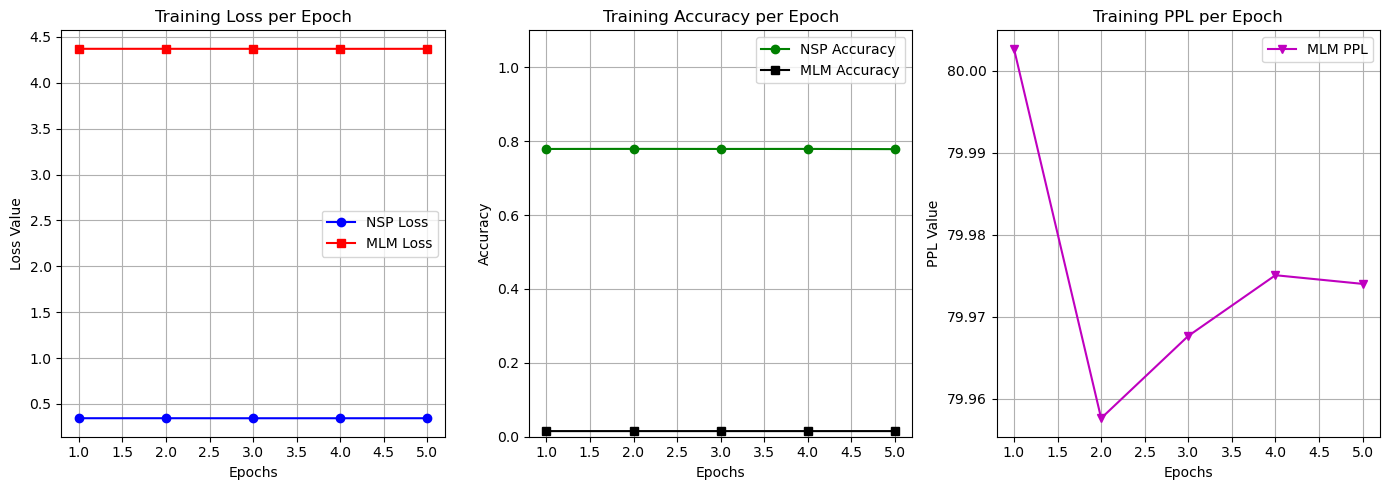

In [67]:
# 시각화
plot_learning_curve(history)

#### 평가 결과 참고
- NSP Accuracy: 78.1% 모델이 문장 순서를 어느 정도 파악하긴 하지만 아직 불안정합니다.  
      (랜덤 추측이 0.5(50%)이며 충분히 학습된 BERT는 보통 95% 이상이 나와야 함)
- MLM Accuracy: 28.7% 랜덤보다는 훨씬 높으니 학습은 되고 있습니다.  
      (랜덤 기준선: 0.01% (1/8000). 충분히 학습된 BERT는 보통 60~80% 수준)

### 2) 유저 테스트 (Inference Playground)

NSP 판별: BERT는 [CLS] 토큰의 벡터를 통해 두 문장의 관계를 이해합니다. 이 코드를 통해 모델이 한국어 문맥을 얼마나 이해했는지 is_next 결과로 볼 수 있습니다.

MLM 복원: [MASK] 토큰 위치의 logits_mlm 값을 확인하여 모델이 단어 사전(8000개) 중 어떤 단어를 가장 높은 확률로 선택했는지 보여줍니다.

In [62]:
def predict_bert(model, vocab, sentence_a, sentence_b, mask_word=None):
    """
    BERT 모델 테스트 함수
    :param mask_token_idx: tokens_a에서 마스킹할 토큰 인덱스 (0부터 시작)
    """
    model.eval()
    
    # 1. 토크나이징
    tokens_a = vocab.encode_as_pieces(sentence_a)
    tokens_b = vocab.encode_as_pieces(sentence_b)
    
    print(f"tokens_a 토크나이징: {tokens_a}")
    print(f"tokens_b 토크나이징: {tokens_b}")

    mask_token_idx = None
    original_token = None
    
    # 특정 단어 마스킹 (입력받은 경우)
    if mask_word and mask_word in tokens_a:
        mask_token_idx = tokens_a.index(mask_word)
        tokens_a[mask_token_idx] = "[MASK]"
    elif mask_word and mask_word in tokens_b:
        mask_token_idx = tokens_b.index(mask_word)
        tokens_b[mask_token_idx] = "[MASK]"
        
    # 2. BERT 입력 포맷 생성 ([CLS] A [SEP] B [SEP])
    tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
    segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)
    
    # 패딩 처리
    enc_token = [vocab.piece_to_id(p) for p in tokens]
    enc_token += [0] * (config.n_seq - len(enc_token))
    segment += [0] * (config.n_seq - len(segment))
    
    # 텐서 변환
    enc_token_tensor = torch.tensor([enc_token]).long().to(device)
    segment_tensor = torch.tensor([segment]).long().to(device)
    
    # 3. 모델 추론
    with torch.no_grad():
        logits_nsp, logits_mlm = model(enc_token_tensor, segment_tensor)

    # 4. NSP 결과
    nsp_prob = torch.softmax(logits_nsp, dim=-1)  # 확률값 출력용
    is_next = torch.argmax(logits_nsp, dim=-1).item()  # 판정용print(f"\n[NSP 결과]")
    
    # 5. MLM 결과
    if mask_token_idx is not None:
        mask_pos = mask_token_idx + 1  # [CLS] 때문에 +1
        top5 = torch.topk(logits_mlm[0, mask_pos], k=5)
        print(f"\n[MLM 결과]")
        print(f"정답 토큰: '{original_token}'")
        print(f"예측 Top5:")
        for rank, (prob, idx) in enumerate(zip(
            torch.softmax(top5.values, dim=-1), top5.indices
        )):
            pred_word = vocab.id_to_piece(idx.item())
            print(f"  {rank+1}위: '{pred_word}' (확률: {prob:.4f})")
            
    
    # MLM 결과 (마스크 위치 찾기)
    print(f"입력 토큰: {tokens}")
    print(f"\n[NSP 결과]")
    print(f"판정: {'연속된 문장 ✅' if is_next == 1 else '연속되지 않은 문장 ❌'}")
    print(f"연속 확률: {nsp_prob[0][1]:.4f} / 비연속 확률: {nsp_prob[0][0]:.4f}")
    
    for i, t in enumerate(tokens):
        if t == "[MASK]":
            pred_id = torch.argmax(logits_mlm[0, i], dim=-1).item()
            pred_word = vocab.id_to_piece(pred_id)
            print(f"빈칸 예측: {pred_word}")

In [63]:
model = loaded_model

# 1. 토크나이징 확인용 (마스킹 인덱스 찾기)
test_sentence = "오늘 날씨가 너무 좋아서 산책을 갔어."
print("토크나이징 확인:", vocab.encode_as_pieces(test_sentence))
print("인덱스:          ", list(enumerate(vocab.encode_as_pieces(test_sentence))))

print("\n" + "="*50)
print("테스트 1: 명확히 연속된 문장")
print("="*50)
predict_bert(model, vocab,
    "오늘 날씨가 너무 좋아서 산책을 갔어.",
    "공원에는 예쁜 꽃들이 많이 피어 있더라.",
    mask_word="좋아"  # '좋아'
)

print("\n" + "="*50)
print("테스트 2: 명확히 비연속된 문장")
print("="*50)
predict_bert(model, vocab,
    "오늘 날씨가 너무 좋아서 산책을 갔어.",
    "주식 시장이 폭락했다.",
)

print("\n" + "="*50)
print("테스트 3: MLM - 다른 단어 마스킹")
print("="*50)
predict_bert(model, vocab,
    "나는 밥을 먹었다.",
    "배가 불러서 낮잠을 잤다.",
    mask_word="먹었다"   # '먹었다'
)

토크나이징 확인: ['▁오늘', '▁날', '씨', '가', '▁너무', '▁좋아', '서', '▁산', '책', '을', '▁', '갔', '어', '.']
인덱스:           [(0, '▁오늘'), (1, '▁날'), (2, '씨'), (3, '가'), (4, '▁너무'), (5, '▁좋아'), (6, '서'), (7, '▁산'), (8, '책'), (9, '을'), (10, '▁'), (11, '갔'), (12, '어'), (13, '.')]

테스트 1: 명확히 연속된 문장
tokens_a 토크나이징: ['▁오늘', '▁날', '씨', '가', '▁너무', '▁좋아', '서', '▁산', '책', '을', '▁', '갔', '어', '.']
tokens_b 토크나이징: ['▁공', '원', '에는', '▁예', '쁜', '▁꽃', '들이', '▁많이', '▁피', '어', '▁있', '더', '라', '.']
입력 토큰: ['[CLS]', '▁오늘', '▁날', '씨', '가', '▁너무', '▁좋아', '서', '▁산', '책', '을', '▁', '갔', '어', '.', '[SEP]', '▁공', '원', '에는', '▁예', '쁜', '▁꽃', '들이', '▁많이', '▁피', '어', '▁있', '더', '라', '.', '[SEP]']

[NSP 결과]
판정: 연속된 문장 ✅
연속 확률: 0.5299 / 비연속 확률: 0.4701

테스트 2: 명확히 비연속된 문장
tokens_a 토크나이징: ['▁오늘', '▁날', '씨', '가', '▁너무', '▁좋아', '서', '▁산', '책', '을', '▁', '갔', '어', '.']
tokens_b 토크나이징: ['▁주', '식', '▁시', '장이', '▁폭', '락', '했다', '.']
입력 토큰: ['[CLS]', '▁오늘', '▁날', '씨', '가', '▁너무', '▁좋아', '서', '▁산', '책', '을', '▁', '갔', '어', '.', '[SEP]', '▁주', 

#### 잘 학습된 BERT의 경우 테스트 결과 예시
테스트 1 (연속):     연속 0.95+ / 비연속 0.05-   ← 높은 확신  
테스트 2 (비연속):   연속 0.05- / 비연속 0.95+   ← 높은 확신  

In [64]:
# 테스트 실행 예시
sentence_1 = "오늘 날씨가 너무 좋아서 산책을 갔어."
sentence_2 = "공원에는 예쁜 꽃들이 많이 피어 있더라."
predict_bert(pre_train_model, vocab, sentence_1, sentence_2, mask_word="산책")

# "산책"이 ▁산, 책으로 토크나이징되어 분리됐기 때문에 tokens_a.index("산책")으로 못 찾음.

tokens_a 토크나이징: ['▁오늘', '▁날', '씨', '가', '▁너무', '▁좋아', '서', '▁산', '책', '을', '▁', '갔', '어', '.']
tokens_b 토크나이징: ['▁공', '원', '에는', '▁예', '쁜', '▁꽃', '들이', '▁많이', '▁피', '어', '▁있', '더', '라', '.']
입력 토큰: ['[CLS]', '▁오늘', '▁날', '씨', '가', '▁너무', '▁좋아', '서', '▁산', '책', '을', '▁', '갔', '어', '.', '[SEP]', '▁공', '원', '에는', '▁예', '쁜', '▁꽃', '들이', '▁많이', '▁피', '어', '▁있', '더', '라', '.', '[SEP]']

[NSP 결과]
판정: 연속된 문장 ✅
연속 확률: 0.5355 / 비연속 확률: 0.4645


### 3) 실무적 효율성 평가 (Efficiency & Deployment)
모델이 아무리 똑똑해도 너무 무겁거나 느리면 서비스에 적용할 수 없습니다. 특히 Mini BERT와 같은 경량화 모델을 개발할 때 핵심적인 지표들입니다.

**추론 지연 시간 (Inference Latency)**  
하나의 요청을 처리하는 데 걸리는 시간(ms)입니다. 실시간 서비스에서는 보통 특정 시간(예: 100ms) 이내에 응답이 와야 합니다.

**모델 크기 및 파라미터 수**  
모델이 차지하는 메모리 용량입니다. 모바일 기기나 저사양 서버 배포 시 중요한 제약 조건이 됩니다.

**Throughput (처리량)**  
단위 시간당 처리할 수 있는 문장의 개수입니다. 서버 비용 효율성과 직결되는 지표입니다.

---

# 9. 회고

### 논문에 나와 있는 Mini 기준 참고
**구글에서 발표한 Well-Read Students Learn Better 논문에 따른 Mini 기준**  
모델 이름, 레이어 수 (n_layer), 숨겨진 차원 (d_model), 파라미터 수 (약)
- BERT-Tiny,2,128,4M
- 현재 내가 만든 모델,3,128,약 5M~6M
- BERT-Mini,4,256,11M
- BERT-Small,4,512,29M
- BERT-Base,12,768,110M

논문을 읽자.

### 훈련을 계속해도 학습이 안되는 경우가 있었다.
첫 시도에서 에포크 2에서 MLM Loss: 8.101418, 에포크 3에서 MLM Loss: 8.101419로 거의 학습이 이루어지지 않았다.  
학습률도 1~3에포크까지 내내 lr=0.000100으로 고정되어 있었다.  
매 배치마다 혹은 최소한 에포크가 변할 때마다 학습률이 미세하게라도 변해야 하는데 거의 변화가 없었다.  
원인으로 추정되는 3가지 - 소프트맥스의 중복으로 인한 기울기 소실, PAD 토큰 학습 방지, lr 스케줄러에 옵티마이저 전달하고 옵티마이저 업데이트하기 등 모든 걸 해봤지만 아직도 loss가 그다지 줄어들지 않고 있다.  

더 깊이 파봐야 할 듯...